In [7]:
import pandas as pd
import geopandas as gpd
import numpy as np
from unidecode import unidecode

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point

import climattr as eea

In [12]:
ips_data = pd.read_csv('data/ips_brasil_municipios.csv')

ips_data['Município'] = ips_data['Município'].apply(lambda x: str(unidecode(x)).upper()[:-5])
ips_data['city_residency'] = ips_data['UF'] + '_' + ips_data['Município']

columns = ['Água e Saneamento', 'PIB per capita 2021',]
ips_data = ips_data[['city_residency'] + columns].rename(columns={'Água e Saneamento': 'water_sanitation', 'PIB per capita 2021': 'pib_2021'})

dummy_data = pd.read_csv('data/ips_brasil_municipios.csv')
dummy_data['Código IBGE'] = dummy_data['Código IBGE'].astype(str)

dummy_data['Município'] = dummy_data['Município'].apply(lambda x: str(unidecode(x)).upper()[:-5])
dummy_data['city_residency'] = dummy_data['UF'] + '_' + dummy_data['Município']

urban_pop = gpd.read_file('utils/sidra_9923_PercPopResidUrbana_mun_22_polPolygon.shp')
urban_pop = urban_pop.set_index('Geocodigo').join(dummy_data.set_index('Código IBGE')[['UF']]).reset_index()

urban_pop['Nome'] = urban_pop['Nome'].apply(lambda x: str(unidecode(x)).upper())
urban_pop['city_residency'] = urban_pop['UF'] + '_' + urban_pop['Nome']

columns = ['PercPopRes', 'PopResidUr']
urban_pop = urban_pop[['city_residency'] + columns].rename(columns={'PercPopRes': 'percent_urban', 'PopResidUr': 'urban_pop'})

inc = pd.read_csv('../peru_dengue/model_input_brazil.csv', parse_dates=['date_first_symptoms'])

inc['month'] = inc['date_first_symptoms'].dt.month
inc['year'] = inc['date_first_symptoms'].apply(lambda x: x.year + 1 if x.month >= 8 else x.year)

pop_year = inc.drop_duplicates(subset=['city_residency', 'year'])[['city_residency', 'year', 'population']]

pop = inc[inc['date_first_symptoms'] == '2020-01-01']

inc = inc.groupby(['region', 'city_residency']).mean(numeric_only=True).reset_index()
inc = inc[['city_residency', 'dengue_inc', 'region']]

pop = pop[['city_residency', 'population']]


In [13]:
df = ips_data.set_index('city_residency').join(urban_pop.set_index('city_residency')).join(inc.set_index('city_residency')).join(pop.set_index('city_residency')).reset_index()

gdf = gpd.read_file('../supplementary/shapefiles/municipios/municipios.shp')
gdf['city_name'] = gdf['SIGLA_UF'] + '_' + gdf['city_name']

df = eea.impacts.geolocate_dataframe(df, gdf, 'city_residency', 'city_name')

pop_year = eea.impacts.geolocate_dataframe(pop_year, gdf, 'city_residency', 'city_name')

/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_27235/755233814.py:87: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap('Greys', n_colors)
/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_27235/755233814.py:97: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pop['centroid'] = pop.geometry.centroid


2004 -45.501571603104885 -16.935015039511956 181743209.0


/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_27235/755233814.py:97: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pop['centroid'] = pop.geometry.centroid


2005 -45.51006648381773 -16.919497576113663 183943232.0


/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_27235/755233814.py:97: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pop['centroid'] = pop.geometry.centroid


...

2022 -45.669450489015226 -16.813506280858313 213338083.0


/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_27235/755233814.py:97: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pop['centroid'] = pop.geometry.centroid


2023 -45.669450489015226 -16.813506280858313 213338083.0


/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_27235/755233814.py:97: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pop['centroid'] = pop.geometry.centroid


2024 -45.669450489015226 -16.813506280858313 213338083.0


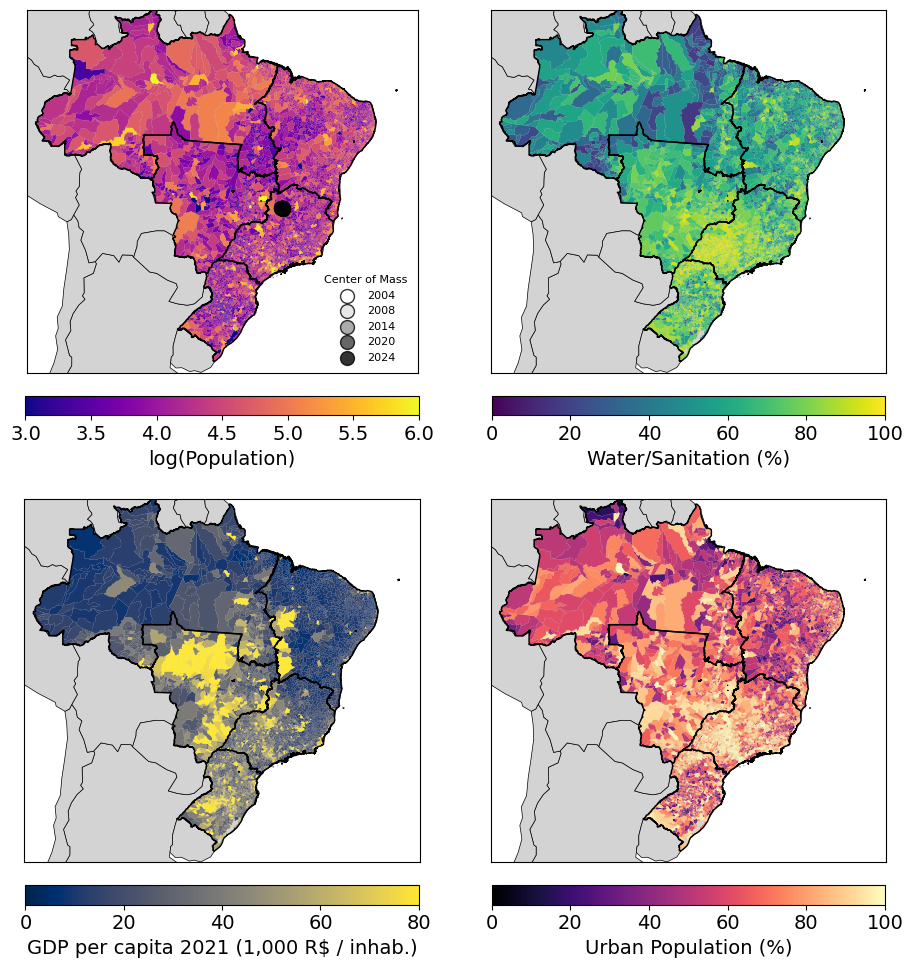

In [16]:
plt.rcParams.update({'font.size': 14})

south_american_countries = [
    "Argentina",
    "Bolivia",
    "Brazil",
    "Chile",
    "Colombia",
    "Ecuador",
    "Guyana",
    "Paraguay",
    "Peru",
    "Suriname",
    "Uruguay",
    "Venezuela",
    "French Guiana",  # Technically an overseas department of France, but often included in geographical maps
    "France"
]

world = gpd.read_file('utils/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')
south_america = world[world['SOVEREIGNT'].isin(south_american_countries)]

region = gpd.read_file('utils/BR_UF_2022/BR_UF_2022.shp')
region_agg = region.dissolve(by='NM_REGIAO')

fig, [[ax1, ax2], [ax3, ax4]] = plt.subplots(2, 2, figsize=(10,10))

df['pib_2021_th'] = df['pib_2021'].astype(float) / 1000
df['log_population'] = df['population'].apply(lambda x: np.log10(x) if x > 0 else 0)

# Brazil map on the left (spans both rows in column 0)
for ax in [ax1, ax2, ax3, ax4]:
    south_america.plot(ax=ax, color='lightgrey', edgecolor='black', lw=0.5)

plot = df.plot(
    ax=ax1,
    vmin=3,
    vmax=6, 
    column='log_population', 
    cmap='plasma',
    legend=True,
    legend_kwds={"label": "log(Population)", "orientation": "horizontal", "pad": 0.05, 'shrink': 0.8}
)

plot = df.plot(
    ax=ax2, 
    column='water_sanitation', 
    vmin=0,
    vmax=100,
    cmap='viridis',
    legend=True,
    legend_kwds={"label": "Water/Sanitation (%)", "orientation": "horizontal", "pad": 0.05, 'shrink': 0.8}
)

plot = df.plot(
    ax=ax3, 
    column='pib_2021_th', 
    vmin=0,
    vmax=80,
    cmap='cividis',
    legend=True,
    legend_kwds={"label": "GDP per capita 2021 (1,000 R$ / inhab.)", "orientation": "horizontal", "pad": 0.05, 'shrink': 0.8}
)

plot = df.plot(
    ax=ax4, 
    column='percent_urban', 
    vmin=0,
    vmax=100,
    cmap='magma',
    legend=True,
    legend_kwds={"label": "Urban Population (%)", "orientation": "horizontal", "pad": 0.05, 'shrink': 0.8}
)

for ax in [ax1, ax2, ax3, ax4]:
    region_agg.plot(ax=ax, color='none', edgecolor='black', lw=1)

    ax.set_xlim([-75, -30])
    ax.set_ylim([-35, 5])
    ax.set_xticks([])
    ax.set_yticks([])

years = np.arange(2004, 2025)
n_colors = len(years)

# Get the colormap
viridis = cm.get_cmap('Greys', n_colors)

# Generate list of colors as hex codes
viridis_colors_hex = [mcolors.to_hex(viridis(i)) for i in range(n_colors)]
sizes = np.linspace(5,100, n_colors)

for year, color, size in zip(years, viridis_colors_hex, sizes):
    pop = pop_year[pop_year['year'] == year].copy()

    # === Step 2: Calculate centroids
    pop['centroid'] = pop.geometry.centroid

    # === Step 3: Get x and y from centroids
    pop['x'] = pop['centroid'].x
    pop['y'] = pop['centroid'].y

    # === Step 4: Compute the weighted average (center of mass)
    total_cases = pop['population'].mean()
    x_com = (pop['x'] * pop['population']).mean() / total_cases
    y_com = (pop['y'] * pop['population']).mean() / total_cases

    print(year, x_com, y_com, pop['population'].sum())

    # === Step 5: Create a GeoSeries for the center of mass
    com_point = gpd.GeoSeries([Point(x_com, y_com)], crs=pop.crs)
    com_point.plot(ax=ax1, color=color, marker='o', markersize=100, alpha=0.8, edgecolor='k')


# === Create dummy legend handles
legend_handles = [
    plt.scatter([], [], s=100, color='#ffffff', label='2004', alpha=0.8, edgecolor='k'),
    plt.scatter([], [], s=100, color='#e2e2e2', label='2008', alpha=0.8, edgecolor='k'),
    plt.scatter([], [], s=100, color='#969696', label='2014', alpha=0.8, edgecolor='k'),
    plt.scatter([], [], s=100, color='#404040', label='2020', alpha=0.8, edgecolor='k'),
    plt.scatter([], [], s=100, color='#000000', label='2024', alpha=0.8, edgecolor='k'),
]

# === Add legend
ax1.legend(handles=legend_handles, loc='lower right', frameon=False, fontsize=8, title='Center of Mass', title_fontsize=8)


plt.tight_layout()
plt.savefig('img/brazil_socioeconomic.pdf', dpi=300, bbox_inches='tight')


In [23]:
df.groupby('region').agg({'population': 'sum'}).sort_values('population') / df['population'].sum()

,population
region,
Middle-West,0.073905
North,0.087416
South,0.145956
Northeast,0.285174
Southeast,0.407550
